# A Transformer block and mixed precision

Runnable locally on CPU or on a Cloud TPU VM.

- Follow the two residual paths
- Normalize features rather than examples
- Test causal independence and differentiation
- Separate storage precision from sensitive arithmetic

An attention head mixes information across positions. What else makes it a Transformer block? We’ll add normalization, a small feature-processing network and two residual connections. Then we’ll inspect gradients and compare a lower-precision version. This is a deliberately small CPU teaching block, not a production architecture.

## The idea

A Transformer block adds learned corrections to token representations. This lesson uses a single attention head, normalization before each branch, and two residual additions. Follow the implemented dimensions rather than assuming all Transformer architectures are interchangeable.

## Follow the residual stream through the actual block

Four token positions each carry eight features. Query/key scores therefore form a four-by-four matrix. Weighted values and the output projection return to eight features, allowing the attention correction to be added to the input.

The feed-forward branch expands eight features to sixteen, applies GELU and returns to eight. It processes each token's feature vector; attention is the part that mixes eligible positions. Each residual addition requires matching shapes.

The saved output-minus-input heatmap shows the combined correction. Its equal rows arise from this fixture's constant-offset input and normalization behavior. They are not a universal property of attention. Use the architecture to identify which input change would test that explanation.

$$
\operatorname{LN}(x)_i = \gamma_i \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta_i, \qquad h^{(\ell+1)} = h^{(\ell)} + f_\ell(\operatorname{LN}(h^{(\ell)}))
$$

### The actual single-head pre-LN block

**Predict:** What should happen when every learned projection is zero?

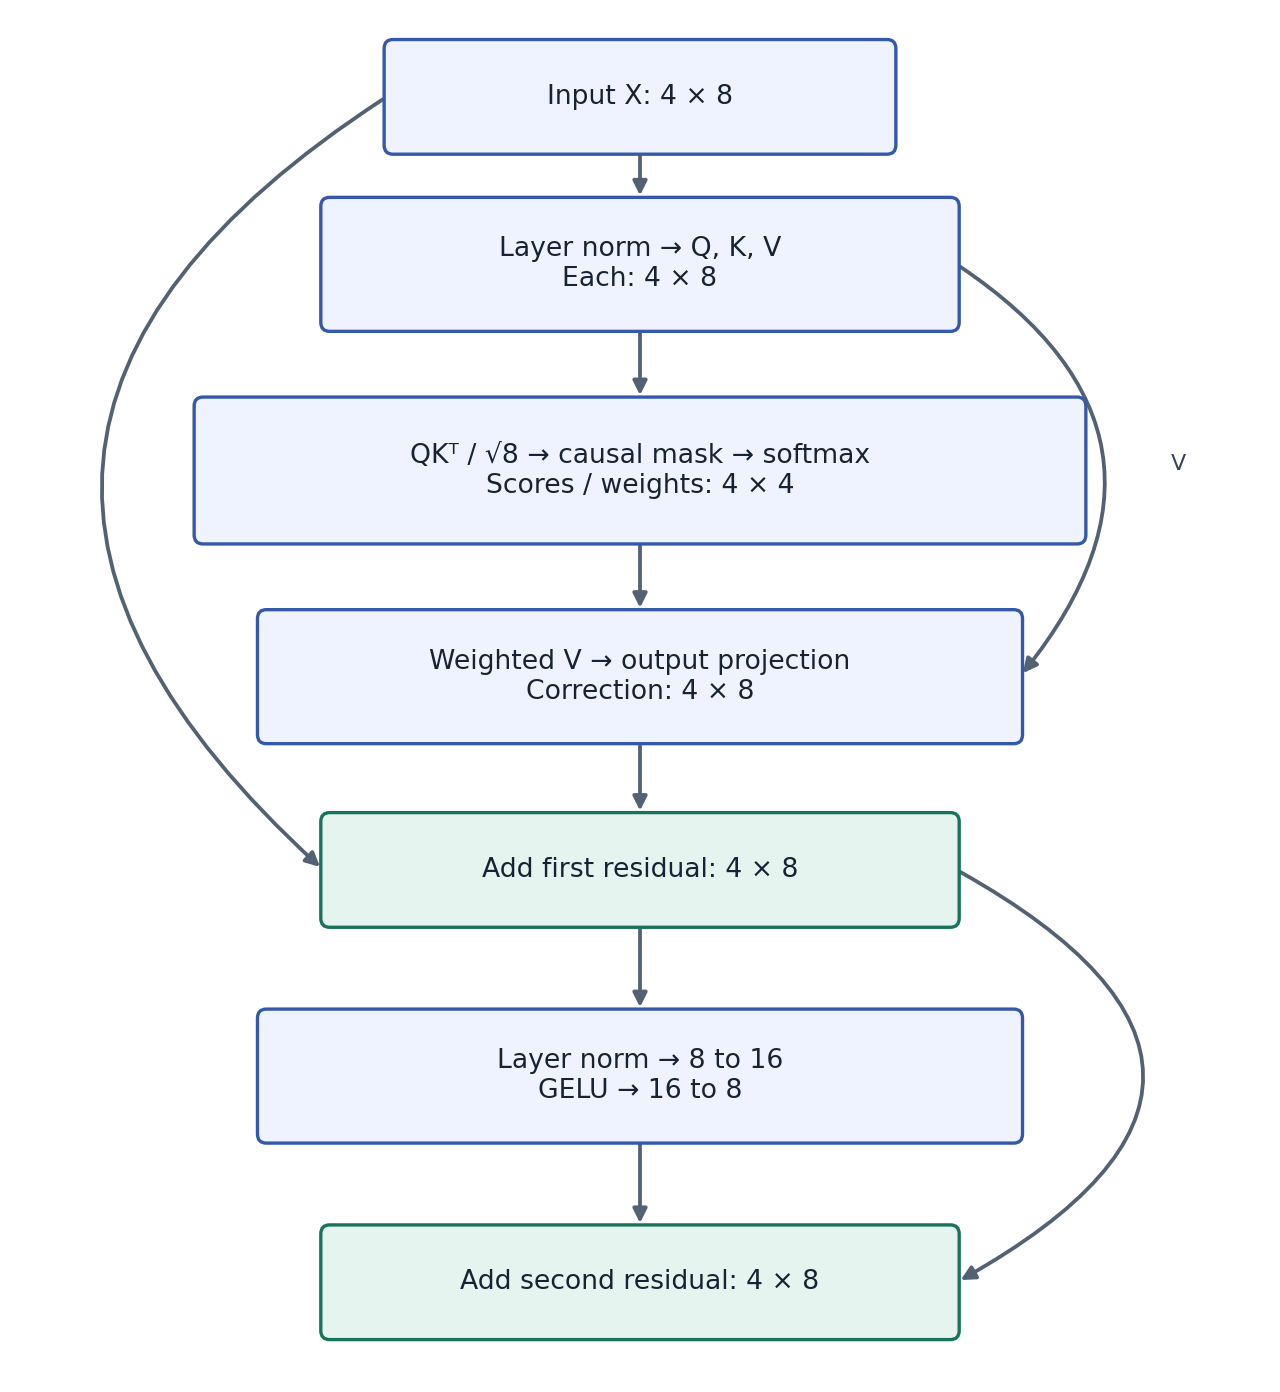

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

The center path carries four positions with eight features. Attention mixes eligible positions through four-by-four weights. The feed-forward branch changes each token from eight to sixteen features and back. Curved bypasses carry residual values to additions. No multihead or cache component is implied.

### Pause and reason

What should happen when every learned projection is zero?

<details><summary>Compare your reasoning</summary>

The block returns its input: both correction branches are zero and the residual path remains. This checks the structure independently of learned performance.

</details>

## Follow the two residual paths

The first sublayer normalizes each token’s features, creates Q/K/V projections, performs causal attention and projects back to the model width. Add that result to the original $x$. The second sublayer normalizes the intermediate residual, expands feature width, applies GELU, contracts back and adds again.

Every residual addition needs matching shapes. Zeroing all six projection matrices makes both sublayers contribute zero, so the block must return $x$ exactly. This is an independent boundary case that catches many incorrect residual connections.

```text
x → norm → Q/K/V → causal attention → output projection
└────────────────────────────── add → residual
residual → norm → expansion → GELU → contraction
└────────────────────────────────── add → output
```

## Normalize features rather than examples

For each token, compute the mean and variance over its feature axis. Subtracting the mean and dividing by `sqrt(variance+epsilon)` makes this sublayer insensitive to a shared finite feature shift, within numerical tolerance. Epsilon prevents division by zero for a constant feature row.

Layer normalization here does not compute statistics across the batch or sequence. Its result has the same shape as its input, and it has no running statistics. Batch normalization and learned affine normalization introduce different state or parameters; do not swap them without revisiting the contract.

## Test causal independence and differentiation

Perturb the last token heavily and verify that the first three output rows stay the same. Pre-normalization and the MLP act per token, while the attention mask prevents earlier queries from reading the last key. A full gradient with respect to the parameter pytree should retain each leaf’s shape and remain finite for this input.

Finite gradients are necessary but not sufficient evidence of a correct block. Check known cases, changed inputs, residual identity and eager/compiled agreement together. The loss reduction determines the gradient scale.

## Separate storage precision from sensitive arithmetic

Casting every parameter and input to bfloat16 is a simple controlled low-precision experiment, not a complete mixed-precision training policy. A common policy stores selected tensors at lower precision while computing reductions and normalization in float32. The second experiment compares fully cast bfloat16 computation with a policy that keeps feature normalization and score softmax in float32, while casting their outputs back for the lower-precision projections.

Record maximum absolute error for the supplied small input; do not require bitwise agreement. Precision affects both small denominators and accumulated dot products. If a comparison fails, inspect normalization and input scale before increasing the tolerance. Real models require workload-specific accuracy and performance qualification.

## 1. Prepare the experiment

In the CPU environment from setup, create main.py and add this block. Write down the dimensions and the known result before continuing.

In [1]:
# Step 1 — 1. Prepare the experiment: These imports provide JAX array transformations and NumPy...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

These imports provide JAX array transformations and NumPy reference calculations. Define the numerical functions next; the final build block supplies the concrete fixture and checks.

## 2. Implement the mechanism

Append this block in the same file. Follow the shape diagram above and identify each reduction or state transition.

In [2]:
# Step 2 — 2. Implement the mechanism: x → norm → Q/K/V → causal attention → output projection...
def layer_norm(x):
    # Reduce along axis=-1 to compute `mean`.
    mean = jnp.mean(x, axis=-1, keepdims=True)
    # Reduce along axis=-1 to compute `variance`.
    variance = jnp.mean((x-mean)**2, axis=-1, keepdims=True)
    # Return `(x - mean) / jnp.sqrt(variance + 1e-05)` to the caller.
    return (x-mean) / jnp.sqrt(variance + 1e-5)

# Function `init_block(key, width)` implementing this stage's computation:
def init_block(key, width=8):
    # Create or split explicit PRNG key(s) (`keys`) for reproducible randomness.
    keys = jax.random.split(key, 6)
    # Compute `shapes` from `[(width,width)]*4 + [(width,2*width),(2*width,width)]`
    shapes = [(width,width)]*4 + [(width,2*width),(2*width,width)]
    # Return `{name: jax.random.normal(k, s) * 0.1 for name, k, s in zip(['q', 'k', 'v', 'o', 'up', 'down'], keys, shapes)}` to the caller.
    return {name: jax.random.normal(k,s)*0.1 for name,k,s in zip(
        ["q","k","v","o","up","down"], keys, shapes)}

# Function `block_forward(p, x)` implementing this stage's computation:
def block_forward(p, x):
    # Run `layer_norm` to compute `h`.
    h = layer_norm(x)
    # Perform matrix contraction / projection to compute `(q, k, v)`.
    q, k, v = h@p["q"], h@p["k"], h@p["v"]
    # Perform matrix contraction / projection to compute `scores`.
    scores = q@k.T / jnp.sqrt(x.shape[-1])
    # Create evenly spaced index values in `allowed`.
    allowed = jnp.arange(x.shape[0])[:,None] >= jnp.arange(x.shape[0])[None,:]
    # Apply nonlinear activation or probability normalization to compute `weights`.
    weights = jax.nn.softmax(jnp.where(allowed, scores, -jnp.inf), axis=-1)
    # Perform matrix contraction / projection to compute `residual`.
    residual = x + (weights@v)@p["o"]
    # Return `residual + jax.nn.gelu(layer_norm(residual) @ p['up']) @ p['down']` to the caller.
    return residual + jax.nn.gelu(layer_norm(residual)@p["up"])@p["down"]

$x$ → norm → Q/K/V → causal attention → output projection
└────────────────────────────── add → residual
residual → norm → expansion → GELU → contraction
└────────────────────────────────── add → output

## 3. Run and check

Append this block and run python main.py. Compare its output with your prediction. An assertion failure means a stated contract needs investigation.

In [3]:
# Step 3 — 3. Run and check: Output shape (4, 8); finite values, zero-projection identity,...
# Create or split explicit PRNG key(s) (`p`) for reproducible randomness.
p = init_block(jax.random.key(7))
# Construct and reshape `x` into the target tensor dimensions.
x = jnp.arange(32, dtype=jnp.float32).reshape(4,8)/10
# Run `block_forward` to compute `output`.
output = block_forward(p, x)
# Check tensor shape invariant: `output.shape == x.shape`
assert output.shape == x.shape
# Ensure all array elements remain finite: `jnp.all(jnp.isfinite(output))`
assert jnp.all(jnp.isfinite(output))
# Transform every leaf of the parameter PyTree (`zero`).
zero = jax.tree.map(jnp.zeros_like, p)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(block_forward(zero, x), x)
# Check numerical equivalence within tolerance: `jnp.allclose(jax.jit(block_forward)(p,x), output, atol=1e-5)`
assert jnp.allclose(jax.jit(block_forward)(p,x), output, atol=1e-5)
# Print the observed values to compare against the expected result.
print("Block shape:", output.shape)

Block shape: (4, 8)


Output shape $(4, 8)$; finite values, zero-projection identity, compiled/eager agreement.

## Run the example

In [4]:
# Step 1 — 1. Prepare the experiment: These imports provide JAX array transformations and NumPy...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Step 2 — 2. Implement the mechanism: x → norm → Q/K/V → causal attention → output projection...
def layer_norm(x):
    # Reduce along axis=-1 to compute `mean`.
    mean = jnp.mean(x, axis=-1, keepdims=True)
    # Reduce along axis=-1 to compute `variance`.
    variance = jnp.mean((x-mean)**2, axis=-1, keepdims=True)
    # Return `(x - mean) / jnp.sqrt(variance + 1e-05)` to the caller.
    return (x-mean) / jnp.sqrt(variance + 1e-5)

# Function `init_block(key, width)` implementing this stage's computation:
def init_block(key, width=8):
    # Create or split explicit PRNG key(s) (`keys`) for reproducible randomness.
    keys = jax.random.split(key, 6)
    # Compute `shapes` from `[(width,width)]*4 + [(width,2*width),(2*width,width)]`
    shapes = [(width,width)]*4 + [(width,2*width),(2*width,width)]
    # Return `{name: jax.random.normal(k, s) * 0.1 for name, k, s in zip(['q', 'k', 'v', 'o', 'up', 'down'], keys, shapes)}` to the caller.
    return {name: jax.random.normal(k,s)*0.1 for name,k,s in zip(
        ["q","k","v","o","up","down"], keys, shapes)}

# Function `block_forward(p, x)` implementing this stage's computation:
def block_forward(p, x):
    # Run `layer_norm` to compute `h`.
    h = layer_norm(x)
    # Perform matrix contraction / projection to compute `(q, k, v)`.
    q, k, v = h@p["q"], h@p["k"], h@p["v"]
    # Perform matrix contraction / projection to compute `scores`.
    scores = q@k.T / jnp.sqrt(x.shape[-1])
    # Create evenly spaced index values in `allowed`.
    allowed = jnp.arange(x.shape[0])[:,None] >= jnp.arange(x.shape[0])[None,:]
    # Apply nonlinear activation or probability normalization to compute `weights`.
    weights = jax.nn.softmax(jnp.where(allowed, scores, -jnp.inf), axis=-1)
    # Perform matrix contraction / projection to compute `residual`.
    residual = x + (weights@v)@p["o"]
    # Return `residual + jax.nn.gelu(layer_norm(residual) @ p['up']) @ p['down']` to the caller.
    return residual + jax.nn.gelu(layer_norm(residual)@p["up"])@p["down"]

# Step 3 — 3. Run and check: Output shape (4, 8); finite values, zero-projection identity,...
# Create or split explicit PRNG key(s) (`p`) for reproducible randomness.
p = init_block(jax.random.key(7))
# Construct and reshape `x` into the target tensor dimensions.
x = jnp.arange(32, dtype=jnp.float32).reshape(4,8)/10
# Run `block_forward` to compute `output`.
output = block_forward(p, x)
# Check tensor shape invariant: `output.shape == x.shape`
assert output.shape == x.shape
# Ensure all array elements remain finite: `jnp.all(jnp.isfinite(output))`
assert jnp.all(jnp.isfinite(output))
# Transform every leaf of the parameter PyTree (`zero`).
zero = jax.tree.map(jnp.zeros_like, p)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(block_forward(zero, x), x)
# Check numerical equivalence within tolerance: `jnp.allclose(jax.jit(block_forward)(p,x), output, atol=1e-5)`
assert jnp.allclose(jax.jit(block_forward)(p,x), output, atol=1e-5)
# Print the observed values to compare against the expected result.
print("Block shape:", output.shape)

Block shape: (4, 8)


Expected: Output shape $(4, 8)$; finite values, zero-projection identity, compiled/eager agreement.

## A residual block adds a correction to its input

Predict: Does a residual connection force the output to equal the input?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: A residual block adds a correction to its input
# Compute `visual_data` from `{'kind': 'heatmap', 'values': (output - x).tolist(),...`
visual_data = {'kind': 'heatmap', 'values': (output - x).tolist(), 'rows': ['token ' + str(i) for i in range(4)], 'columns': ['f' + str(i) for i in range(8)], 'unit': 'output minus input', 'diverging': True}

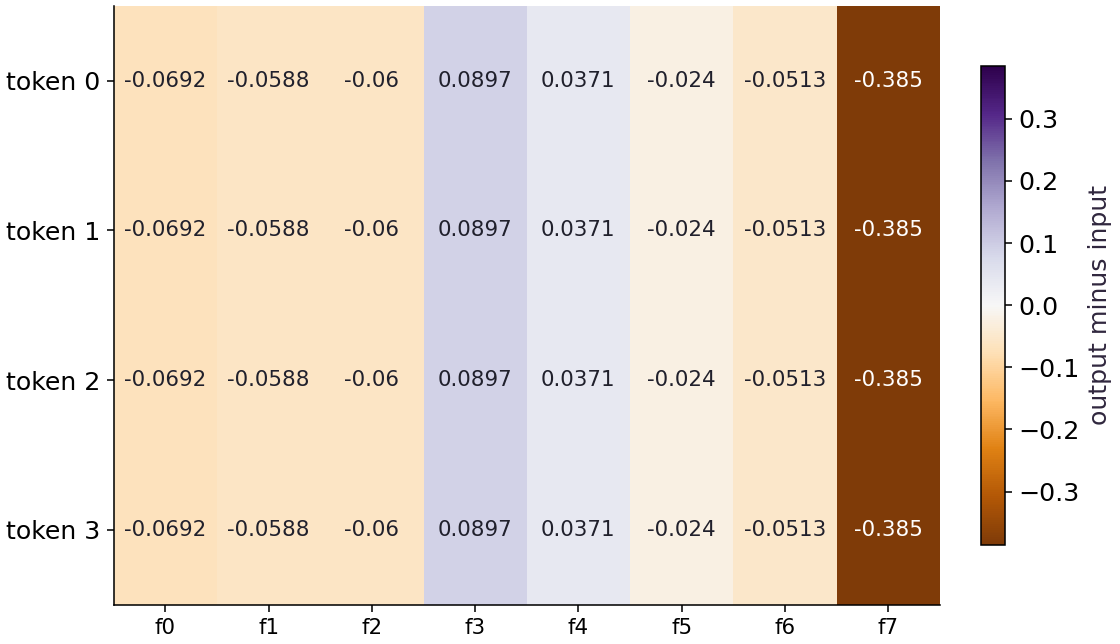

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Rows are token positions and columns are features. Every cell shows output minus input at that location, so this is a map of the block’s correction, not its raw output. Purple indicates a positive correction, brown a negative correction, and near-white little change.

Feature $3$ increases by about $0.0897$, while feature $7$ decreases by about $0.385$. Those same column patterns repeat across all four rows, up to floating-point rounding. The strongest color marks the largest change in magnitude, not the feature with the largest original activation.

### Connect it to the computation

Why do the rows look identical? The example builds input rows that differ only by a constant offset across their features. Per-token layer normalization removes that offset, so the normalized rows match. Their projected values match too, so attention’s weighted average is the same even when the causal mask allows different numbers of tokens. The subsequent normalized feed-forward branch preserves this symmetry.

The block therefore adds almost the same correction to different input rows; the final rows themselves are still different. This repeated pattern comes from the chosen input, not a rule that transformers treat every token identically. Change one feature of one token, rather than shifting the entire row, to break the symmetry and inspect how the correction changes.

## Verify the residual identity and causal boundary

Predict: Which output rows can change when only the last token changes?

In [7]:
# Experiment — Verify the residual identity and causal boundary: Masking and per-token operations preserve causal independence...
changed_x = x.at[-1].add(100.)
# Run `block_forward` to compute `changed_output`.
changed_output = block_forward(p, changed_x)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(changed_output[:3], output[:3], atol=1e-5)
# Check numerical equivalence within tolerance: `not jnp.allclose(changed_output[-1], output[-1])`
assert not jnp.allclose(changed_output[-1], output[-1])

Expected: First three rows agree; the last row changes.

Masking and per-token operations preserve causal independence through both sublayers.

## Compare two precision policies

Predict: Which operations use float32 in mixed_block? Will its error necessarily be smaller for every input?

In [8]:
# Experiment — Compare two precision policies: Storage/activation casts and sensitive-reduction precision are...
# Transform every leaf of the parameter PyTree (`low_p`).
low_p = jax.tree.map(lambda z:z.astype(jnp.bfloat16), p)
# Cast or evaluate `low_x` in explicit floating-point precision.
low_x = x.astype(jnp.bfloat16)
# Cast or evaluate `low_out` in explicit floating-point precision.
low_out = block_forward(low_p, low_x).astype(jnp.float32)
# Aggregate array values to compute `error`.
error = jnp.max(jnp.abs(low_out-output))
# Print the observed values to compare against the expected result.
print("bfloat16 max absolute error:", float(error))
# Confirm that all computed values remain finite (no NaN or Inf).
assert jnp.all(jnp.isfinite(low_out))
# Assert invariant `error < 0.1` holds
assert error < 0.1

# Function `mixed_block(p, x)` implementing this stage's computation:
def mixed_block(p, x):
    # Cast or evaluate `h` in explicit floating-point precision.
    h = layer_norm(x.astype(jnp.float32)).astype(jnp.bfloat16)
    # Perform matrix contraction / projection to compute `(q, k, v)`.
    q,k,v = h@p["q"], h@p["k"], h@p["v"]
    # Cast or evaluate `scores` in explicit floating-point precision.
    scores = (q@k.T).astype(jnp.float32)/jnp.sqrt(x.shape[-1])
    # Create evenly spaced index values in `allowed`.
    allowed = jnp.arange(x.shape[0])[:,None] >= jnp.arange(x.shape[0])[None,:]
    # Cast or evaluate `weights` in explicit floating-point precision.
    weights = jax.nn.softmax(jnp.where(allowed,scores,-jnp.inf),axis=-1).astype(jnp.bfloat16)
    # Perform matrix contraction / projection to compute `residual`.
    residual = x+(weights@v)@p["o"]
    # Cast or evaluate `normalized` in explicit floating-point precision.
    normalized = layer_norm(residual.astype(jnp.float32)).astype(jnp.bfloat16)
    # Cast or evaluate `activation` in explicit floating-point precision.
    activation = jax.nn.gelu((normalized@p["up"]).astype(jnp.float32)).astype(jnp.bfloat16)
    # Return `residual + activation @ p['down']` to the caller.
    return residual + activation@p["down"]

# Cast or evaluate `mixed_out` in explicit floating-point precision.
mixed_out = mixed_block(low_p,low_x).astype(jnp.float32)
# Aggregate array values to compute `mixed_error`.
mixed_error = jnp.max(jnp.abs(mixed_out-output))
# Print the observed values to compare against the expected result.
print("Float32 reduction policy max absolute error:",float(mixed_error))
# Ensure all array elements remain finite: `jnp.all(jnp.isfinite(mixed_out))`
assert jnp.all(jnp.isfinite(mixed_out))
# Assert invariant `mixed_error < 0.1` holds
assert mixed_error < 0.1

bfloat16 max absolute error: 0.013455629348754883
Float32 reduction policy max absolute error: 0.013455629348754883


Expected: Both outputs are finite, with max absolute errors below $0.1$ for this fixture. Record both actual errors; their relative order is not guaranteed.

Storage/activation casts and sensitive-reduction precision are separate choices. One fixture is distinct from an accuracy or throughput guarantee.

## Your exercise

Differentiate the mean squared block output with respect to every projection. Check each gradient leaf’s shape and finite values, then perturb one parameter coordinate and compare a central difference.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jnp.isfinite(x)` — Returns a boolean mask verifying that no element is `NaN` or `Inf`.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Return `jnp.mean(block_forward(params, x) ** 2)` to the caller.
2. Differentiate the objective to obtain `g` via automatic differentiation.
3. Check tensor shape invariant: `all(a.shape==b.shape and jnp.all(jnp.isfinite(b)) for a,b in zip(...`
4. Function `shifted_objective(delta)` implementing this stage's computation:
5. Compute `altered` from `{**p, "down": p["down"].at[0,0].add(delta)}`

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Differentiate the mean squared block output with respect to every...
def objective(params):
    # Return `jnp.mean(block_forward(params, x) ** 2)` to the caller.
    return ...  # TODO: return computed result
# Differentiate the objective to obtain `g` via automatic differentiation.
g = jax.grad(...)  # TODO: compute g
# Check tensor shape invariant: `all(a.shape==b.shape and jnp.all(jnp.isfinite(b)) for a,b in zip(...`
assert all(a.shape  # TODO: complete assertion check
# Function `shifted_objective(delta)` implementing this stage's computation:
def shifted_objective(delta):
    # Compute `altered` from `{**p, "down": p["down"].at[0,0].add(delta)}`
    altered = ...  # TODO: compute altered
    # Return `objective(altered)` to the caller.
    return ...  # TODO: return computed result
# Compute `fd` from `(shifted_objective(1e-2)-shifted_objective(-1e-2))/(...`
fd = ...  # TODO: compute fd
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(fd,g["down"][0,0],atol=1e-4,rtol=2e-2)  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Differentiate the mean squared block output with respect to every...
# def objective(params):
    # Return `jnp.mean(block_forward(params, x) ** 2)` to the caller.
#     return ...  # TODO: return computed result
# Differentiate the objective to obtain `g` via automatic differentiation.
# g = jax.grad(...)  # TODO: compute g
# Check tensor shape invariant: `all(a.shape==b.shape and jnp.all(jnp.isfinite(b)) for a,b in zip(...`
# assert all(a.shape  # TODO: complete assertion check
# Function `shifted_objective(delta)` implementing this stage's computation:
# def shifted_objective(delta):
    # Compute `altered` from `{**p, "down": p["down"].at[0,0].add(delta)}`
#     altered = ...  # TODO: compute altered
    # Return `objective(altered)` to the caller.
#     return ...  # TODO: return computed result
# Compute `fd` from `(shifted_objective(1e-2)-shifted_objective(-1e-2))/(...`
# fd = ...  # TODO: compute fd
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(fd,g["down"][0,0],atol=1e-4,rtol=2e-2)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Differentiate the mean squared block output with respect to every...
def objective(params):
    # Return `jnp.mean(block_forward(params, x) ** 2)` to the caller.
    return jnp.mean(block_forward(params,x)**2)
# Differentiate the objective to obtain `g` via automatic differentiation.
g = jax.grad(objective)(p)
# Check tensor shape invariant: `all(a.shape==b.shape and jnp.all(jnp.isfinite(b)) for a,b in zip(...`
assert all(a.shape==b.shape and jnp.all(jnp.isfinite(b)) for a,b in zip(jax.tree.leaves(p),jax.tree.leaves(g)))
# Function `shifted_objective(delta)` implementing this stage's computation:
def shifted_objective(delta):
    # Compute `altered` from `{**p, "down": p["down"].at[0,0].add(delta)}`
    altered = {**p, "down": p["down"].at[0,0].add(delta)}
    # Return `objective(altered)` to the caller.
    return objective(altered)
# Compute `fd` from `(shifted_objective(1e-2)-shifted_objective(-1e-2))/(...`
fd = (shifted_objective(1e-2)-shifted_objective(-1e-2))/(2e-2)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(fd,g["down"][0,0],atol=1e-4,rtol=2e-2)

## Check normalization without autodiff · Transfer / diagnosis

Compute the first normalized row using NumPy and compare. Also check a constant row.

Hint: Use population variance over features and epsilon $10^{-5}$.

### How to write: Check normalization without autodiff — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.zeros / jnp.ones(shape, dtype=...)` — Allocates a tensor of the given `shape` initialized with constants.
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Aggregate array values to compute `reference`.
2. Check numerical equivalence within tolerance: `np.testing.assert_allclose(layer_norm(x)[0],reference,atol=1e-6)`
3. Verify that the numerical values match the expected reference within tolerance.

**Starter code scaffold (fill in the TODOs):**

```python
# Check normalization without autodiff (Transfer / diagnosis): The independent reduction and constant-row case check the...
row = np.asarray(...)  # TODO: compute row
# Aggregate array values to compute `reference`.
reference = ...  # TODO: compute reference
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(layer_norm(x)[0],reference,atol=1e-6)`
np.testing.assert_allclose(layer_norm(x)[0],reference,atol = ...  # TODO: compute np.testing.assert_allclose(layer_norm(x)[0],reference,atol
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(layer_norm(jnp.ones((2,8))),0.)  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Check normalization without autodiff (Transfer / diagnosis): The independent reduction and constant-row case check the...
# row = np.asarray(...)  # TODO: compute row
# Aggregate array values to compute `reference`.
# reference = ...  # TODO: compute reference
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(layer_norm(x)[0],reference,atol=1e-6)`
# np.testing.assert_allclose(layer_norm(x)[0],reference,atol = ...  # TODO: compute np.testing.assert_allclose(layer_norm(x)[0],reference,atol
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(layer_norm(jnp.ones((2,8))),0.)  # TODO: complete assertion check

## Reference reasoning

The independent reduction and constant-row case check the normalization mechanism.

In [12]:
# Check normalization without autodiff (Transfer / diagnosis): The independent reduction and constant-row case check the...
row = np.asarray(x[0])
# Aggregate array values to compute `reference`.
reference = (row-row.mean())/np.sqrt(np.mean((row-row.mean())**2)+1e-5)
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(layer_norm(x)[0],reference,atol=1e-6)`
np.testing.assert_allclose(layer_norm(x)[0],reference,atol=1e-6)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(layer_norm(jnp.ones((2,8))),0.)

## Repair a residual width mismatch · Transfer / diagnosis

Remove the contraction from the MLP and reproduce the residual addition failure. Restore the contraction and verify shape.

Hint: The expanded tensor has twice the model width.

### How to write: Repair a residual width mismatch — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `mismatch(...)` — Call `mismatch` with your updated parameters or inputs from this lesson's workspace.
- `nn.gelu(...)` — Call `nn.gelu` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Check tensor shape invariant: `expanded.shape == (4,16)`
2. Run the boundary check and catch the expected exception:
3. Check tensor shape invariant: `(x + expanded@p["down"]).shape == x.shape`

**Starter code scaffold (fill in the TODOs):**

```python
# Repair a residual width mismatch (Transfer / diagnosis): Residual paths require matching widths; the down projection...
expanded = jax.nn.gelu(...)  # TODO: compute expanded
# Check tensor shape invariant: `expanded.shape == (4,16)`
assert expanded.shape  # TODO: complete assertion check
# Run the boundary check and catch the expected exception:
try:
    _ = ...  # TODO: compute _
except TypeError:
    pass
else:
    raise AssertionError("expected width mismatch")
# Check tensor shape invariant: `(x + expanded@p["down"]).shape == x.shape`
assert (x + expanded@p["down"]).shape  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Repair a residual width mismatch (Transfer / diagnosis): Residual paths require matching widths; the down projection...
# expanded = jax.nn.gelu(...)  # TODO: compute expanded
# Check tensor shape invariant: `expanded.shape == (4,16)`
# assert expanded.shape  # TODO: complete assertion check
# Run the boundary check and catch the expected exception:
# try:
#     _ = ...  # TODO: compute _
# except TypeError:
#     pass
# else:
#     raise AssertionError("expected width mismatch")
# Check tensor shape invariant: `(x + expanded@p["down"]).shape == x.shape`
# assert (x + expanded@p["down"]).shape  # TODO: complete assertion check

## Reference reasoning

Residual paths require matching widths; the down projection restores the model-width contract.

In [14]:
# Repair a residual width mismatch (Transfer / diagnosis): Residual paths require matching widths; the down projection...
expanded = jax.nn.gelu(layer_norm(x)@p["up"])
# Check tensor shape invariant: `expanded.shape == (4,16)`
assert expanded.shape == (4,16)
# Run the boundary check and catch the expected exception:
try:
    _ = x + expanded
except TypeError:
    pass
else:
    raise AssertionError("expected width mismatch")
# Check tensor shape invariant: `(x + expanded@p["down"]).shape == x.shape`
assert (x + expanded@p["down"]).shape == x.shape

## Checkpoint

If all projection matrices are zero in this block, what should the output be?

1. Zero
2. The original input
3. Undefined because attention has zero scores

## Diagnose

A residual width error means the expanded MLP tensor was added before its contraction. Check $(T,2D)$ versus $(T,D)$, restore the down projection and verify the zero-projection identity. For nonfinite or inaccurate lower-precision results, inspect feature variance, epsilon and reduction dtype. Report both measured precision errors rather than assuming a policy must always improve them.

## Evidence

Keep the architecture diagram, zero-projection identity, causal perturbation, independent normalization, finite-difference coordinate check, precision discrepancy and residual-width repair.

## Carry forward

- Masking and per-token operations preserve causal independence through both sublayers.
- The error bound is a checked example, not an accuracy guarantee for arbitrary models.

## Primary references

- [JAX softmax API](https://docs.jax.dev/en/latest/_autosummary/jax.nn.softmax.html)
- [JAX attention API](https://docs.jax.dev/en/latest/_autosummary/jax.nn.dot_product_attention.html)
- [Optax cross entropy](https://optax.readthedocs.io/en/latest/api/losses.html)